## **Task 1: Identifying the Prediction Target**

In [1]:
import pandas as pd
df = pd.read_csv("bank-additional.csv", sep=';')
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

In [3]:
df[['y', 'poutcome', 'default']].describe()

,y,poutcome,default
count,4119,4119,4119
unique,2,3,3
top,no,nonexistent,no
freq,3668,3523,3315


The target variable is y, as it indicates whether the client subscribed to the term deposit (yes/no). This directly reflects the success of the marketing campaign, making it the appropriate prediction objective.

A potential alternative could be poutcome, but this represents the outcome of a previous campaign, not the current one. It is therefore a historical feature rather than the target.

Another possible option is default, since it is categorical. However, it relates to credit risk and not to the marketing campaign outcome. Using it would change the problem.



## **Task 2: Data Loading and Exploration**

This is the next task because before we can continue with anything else we need to load in our data and explore it in order to understand what we are working with.

**Load the dataset into a Pandas DataFrame.**

In [4]:
# already did in task 1

**Inspect the structure of the dataset: number of observations, number of features, data types, and basic
summary statistics.**

In [5]:
df.shape

(4119, 21)

4119 observations and 21 features, each observation representing a client contacted during the campaign

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

Here we can view the datatypes:
* int64 = integer and float64 = float being the numerical variables
* str = string being the categorical variables

In [7]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


These are the summary statistics for our numerical variables:

In [8]:
df.describe(include="str")

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119,4119
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,1012,2509,1264,3315,2175,3349,2652,1378,860,3523,3668


These are the summary statistics for our categorical variables: job, marital, education, default, housing, loan, contact, month, day_of_week, poutcome, y

**Analyze the distribution of the target variable and comment on potential class imbalance.**

In [9]:
print(df["y"].value_counts())
print(df["y"].value_counts(normalize=True))

y
no     3668
yes     451
Name: count, dtype: int64
y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64


The target variable y is highly imbalanced, with roughly 89% “no” and 11% “yes”. This imbalance may bias the model toward predicting the majority class and inflate accuracy. Therefore, stratified splitting and appropriate evaluation metrics (e.g., precision and recall) will be necessary.

**Detect explicit and implicit missing values (e.g., special categories such as unknown).**

In [10]:
print(df.isna().sum())
print((df == "unknown").sum())

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64
age                 0
job                39
marital            11
education         167
default           803
housing           105
loan              105
contact             0
month               0
day_of_week         0
duration            0
campaign            0
pdays               0
previous            0
poutcome            0
emp.var.rate        0
cons.price.idx      0
cons.conf.idx       0
euribor3m           0
nr.employed         0
y                   0
dtype: int64


Based on these results, there are no explicit missing values in our dataset, however, we do have implicit missing values ("unknown") in job, marital, education, housing, loan and most notably in default (803 instances). This means we should proceed with care when it comes to using these variables, we would need to make a clear decision on what to do: impute or treat as a separate category. This implicit missingness could also carry some predictive power so removing without valid justification would be wrong.

**Visualize the distribution of at least:
– two numerical variables; and
– two categorical variables.**

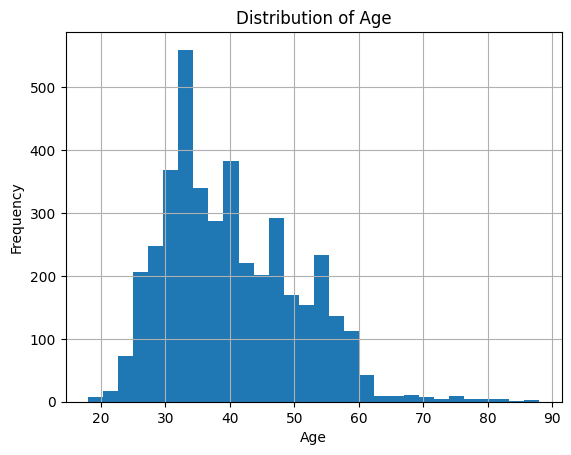

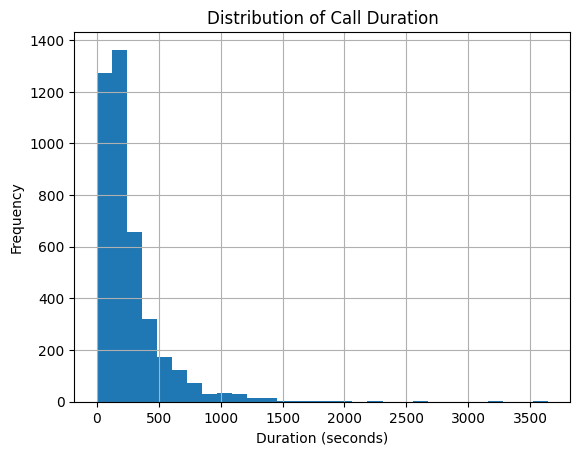

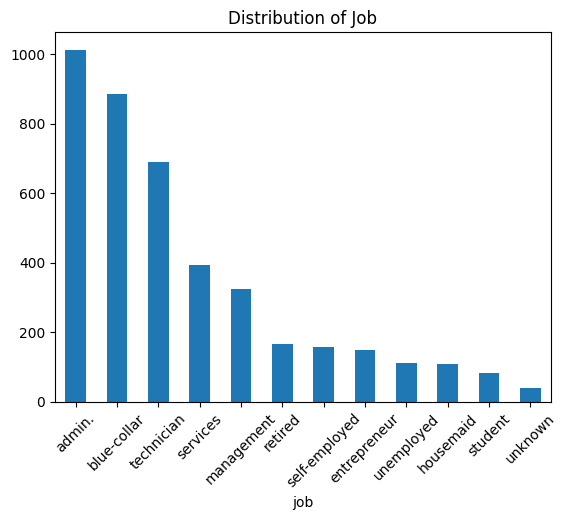

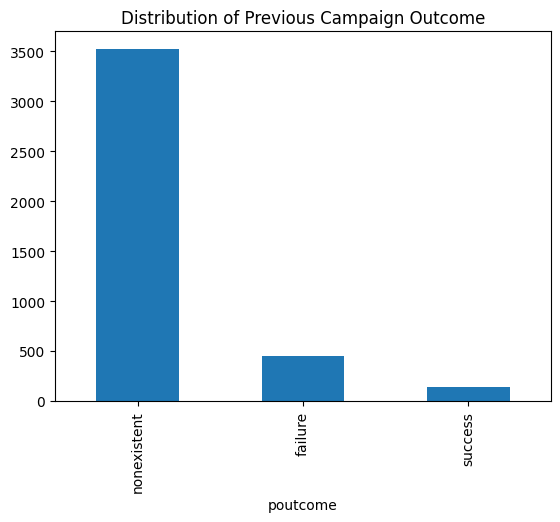

In [11]:
import matplotlib.pyplot as plt

#Numerical Variable Plots

plt.figure()
df["age"].hist(bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

plt.figure()
df["duration"].hist(bins=30)
plt.title("Distribution of Call Duration")
plt.xlabel("Duration (seconds)")
plt.ylabel("Frequency")
plt.show()

#Categorical Variable Plots
plt.figure()
df["job"].value_counts().plot(kind="bar")
plt.title("Distribution of Job")
plt.xticks(rotation=45)
plt.show()

plt.figure()
df["poutcome"].value_counts().plot(kind="bar")
plt.title("Distribution of Previous Campaign Outcome")
plt.show()

The distribution of age appears slightly right-skewed, with most clients concentrated between 30 and 50 years old, suggesting no extreme irregularities but indicating that scaling may later be required. Duration is highly right-skewed, with many short calls and a few very long ones. This skewness may affect model stability, and more importantly, call duration may not be available at prediction time, raising data leakage concerns. The categorical variable job shows uneven category frequencies, which may influence encoding decisions and coefficient stability in Logistic Regression. Finally, poutcome is dominated by the category “nonexistent”, indicating that most clients had no previous campaign interaction, though the minority categories may still carry predictive information.

**Identify at least one variable that may require special consideration before modeling (e.g., due to distributional
properties, extreme skewness, or availability at prediction time), and briefly justify your reasoning.**
The variable duration requires special attention for two reasons:
* It is highly right-skewed.
* More importantly, it may not be available at prediction time, since call duration is determined after the call ends.

Including it without justification could introduce data leakage and artificially inflate model performance.

## **Task 3: Data Splitting**

1. Split the dataset into training, validation, and test sets.
2. Justify your choice of proportions for each split.
3. Perform stratified splitting with respect to the target variable and explain why stratification is necessary for this dataset.
4. Clearly describe at which stage of your pipeline the split must occur, and explain what types of data leakage would arise if splitting were performed later.

In [12]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["y"])
y = df["y"]

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

First of all, the training set must be the highest. I decided to make that 70% leaving 15% for the validation and 15% for the test set respectively. The training set needs a good amount of data so that we can properly train our model and  identify model parameters. allocating the remaining 30% to validation and test to split evenly seemed reasonable as validation will be used for sanity checks and test will only be used once at the end. This sort of split is commonly used in the machine learning world as a good balance between model training and evaluation.

Stratification is necessary for this dataset because as we had identified before, our target variable y was imbalanced, so this would have led to a bias model with yes (minority class) being underrepresented. By doing stratification, the original proportion will be preserved across splits.

The data splitting must strictly be performed before any sort of preprocessing. This is due to the fact that if it were performed after, it would lead to data leakage from validation/test sets into the training set, as the imputation, encoding, feature selection etc. would be done with access to the whole dataset, indirectly accessing test data, and this would make for a unreliable model.

## **Task 4: Managing Missing Values**

1. Identify both explicit missing values (e.g., NaN) and implicit missing values (e.g., categories such as unknown or sentinel numerical values, i.e., values that may represent special codes rather than genuine measurements).
2. Quantify the extent of missingness for each affected variable.
3. Propose and justify a strategy for handling missing values in each case (e.g., removal, imputation, separate category, indicator variable).
4. Clearly state which operations must be fitted using the training set only, and explain why.

In [13]:
# Checking the overall train set
print(X_train)

      age            job   marital            education  default housing loan  \
1948   49        retired  divorced  professional.course       no     yes  yes   
2198   44   entrepreneur  divorced             basic.4y       no      no   no   
166    32         admin.   married    university.degree       no     yes   no   
2152   44    blue-collar    single             basic.9y       no     yes  yes   
2881   33         admin.    single          high.school       no      no   no   
...   ...            ...       ...                  ...      ...     ...  ...   
416    43    blue-collar   married             basic.4y       no      no  yes   
1487   53       services   married          high.school  unknown     yes   no   
2895   30    blue-collar    single             basic.9y  unknown     yes   no   
3566   28  self-employed    single             basic.9y       no      no   no   
3951   49       services   married             basic.6y       no      no  yes   

        contact month day_o

In [14]:
print(X_train.isna().sum()) # Shows me any missing values
print((X_train == "unknown").sum()) # Shows me total "unknown" for each variable

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
dtype: int64
age                 0
job                25
marital             7
education         112
default           577
housing            65
loan               65
contact             0
month               0
day_of_week         0
duration            0
campaign            0
pdays               0
previous            0
poutcome            0
emp.var.rate        0
cons.price.idx      0
cons.conf.idx       0
euribor3m           0
nr.employed         0
dtype: int64


Here we have identified our explicit missing values (none) and our implicit missing values where the text is "unknown". Defualt is the variable with the most implicit missing values. These implicit missing values could carry some predictive power they will be retained and treated as a separate category rather than removed or imputed.

In [15]:
print(X_train["pdays"].value_counts())

pdays
999    2764
3        41
6        30
4        11
7         7
10        6
12        5
2         3
13        2
1         2
18        2
9         2
15        2
0         2
16        1
5         1
19        1
17        1
Name: count, dtype: int64


So many 999 values in pdays seemed odd. I decided to explore further and by looking at the amount of times 999 appears, it seemed like it could be a sentinel value. Further exploring the documentation in the zip file, I found "(numeric; 999 means client was not previously contacted)", and this confirms my intuition that 999 was indeed a sentinel value that reflects the client not being contacted. Now because of this, we can not leave 999 as is as the model would interpret it as a very large number so what we could do is use it for binary indication, if 999 then not contacted if not 999 then contacted.

All preprocessing operations that estimate parameters from data must be fitted using the training set only. In this case, since the category "unknown" is retained rather than imputed, and the sentinel value in pdays is transformed into a binary indicator, no distribution-based parameters are learned at this stage. Nevertheless, this step must still occur after data splitting to maintain pipeline discipline.

## **Task 5: Encoding Categorical Variables**

1. Identify all categorical variables in the dataset.
2. Distinguish between nominal variables (categories without intrinsic order, e.g., job type) and ordinal variables (categories with a meaningful order, e.g., education level), and justify your classification.
3. Select and apply an appropriate encoding strategy for each categorical variable.
4. Clearly state which encoders must be fitted on the training set only, and explain why.
5. Analyze how encoding changes:
– the dimensionality of the dataset;
– the interpretability of model coefficients;
– the types of decision boundaries a linear model can represent.

In [16]:
categorical_variables = ["job", "marital", "education", "default", "housing", "loan",
    "contact", "month", "day_of_week", "poutcome"]

nominal_var =["job", "marital", "default", "housing", "loan",
    "contact", "month", "day_of_week", "poutcome"]

ordinal_var = ["education"]

Out of all the categorical variables, education is the only one where there is an actual hierarchy or meaningful ranking as it is the level of education.

* For the nominal variables I will use one-hot encoding as this creates a binary indicator for each job (note: increases the dimensionality of data) that will not distort our logistic regression model by imposing ordinality.
* For the ordinal variable I will use ordinal encoding as this will capture the hierarchical structure of the data.

In [17]:
X_train["education"].unique() #checking each level of education so I can order them in a list

<StringArray>
['professional.course',            'basic.4y',   'university.degree',
            'basic.9y',         'high.school',            'basic.6y',
             'unknown',          'illiterate']
Length: 8, dtype: str

In [18]:
education_order = [ "illiterate", "basic.4y", "basic.6y", "basic.9y", "high.school",
"professional.course", "university.degree", "unknown" ]

In [19]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Encoders
onehot_enc = OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)

ordinal_enc = OrdinalEncoder(
    categories=[education_order],
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

# Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("edu_ord", ordinal_enc, ordinal_var),
        ("nom_ohe", onehot_enc, nominal_var),
    ],
    remainder="passthrough"  # keeps numerical columns same
)

# Fit on training, transform train/val/test
X_train_enc = preprocessor.fit_transform(X_train)
X_val_enc   = preprocessor.transform(X_val)
X_test_enc  = preprocessor.transform(X_test)

Both encoders we have used must strictly be used on the training set because if not, the model would have indirectly gained access to information and data in the validation and test sets leading to data leakage and a misleading final model performance. What we have done to the test and validation sets is simply transform them accordingly with the mappings done in our encoding on the training set, no information is learned from this.

In [20]:
print(X_train.shape)
print(X_train_enc.shape)

(2883, 20)
(2883, 47)


* The dimensionality of our training set has increased from 20 to 47, that is more than two times. This was due to the one-hot encoding we did as it created a new column for each category (except reference). The ordinal encoding we did not affect the dimensionality.
* With one-hot encoding, it is always relative to the reference category. So if the coefficient is greater than 0, then the log odds is increased and if the coefficient is less than 0 then the log odds decrease. With ordinal encoding, the coefficient shows the change in log odds when we move a level higher or lower.
* With one-hot encoding, since each category gets its own separate indicator variables, the model is able to treat them independently without the assumption of relationship between them. With ordinal encoding, the model assumes order in the categories and therefore higher and lower values have consistent effects on the prediction. For instance if we had done ordinal encoding for nominal variables, then the model would have assigned more value to a category based on the numerical ranking when in reality no such relationship exists in real life.

## **Task 6: Feature Scaling**

1. Identify the numerical variables that require scaling.
2. Select and apply an appropriate scaling strategy (e.g., standardization or normalization) to those variables.
3. Justify your choice of scaling method in the context of Logistic Regression.
4. Clearly state which transformations must be fitted on the training set only, and explain why.
5. Discuss how feature scaling affects: – gradient-based optimization;
– the magnitude and comparability of model coefficients;
– the interpretation of regularization penalties.

In [21]:
 # After encoding turn it back into a pandas dataframe
feature_names = preprocessor.get_feature_names_out()

X_train_enc = pd.DataFrame(X_train_enc, columns=feature_names, index=X_train.index)
X_val_enc   = pd.DataFrame(X_val_enc, columns=feature_names, index=X_val.index)
X_test_enc  = pd.DataFrame(X_test_enc, columns=feature_names, index=X_test.index)

In [22]:
numeric_cols = X_train_enc.select_dtypes(include=["int64", "float64"]).columns

binary_cols = [
    col for col in numeric_cols
    if set(X_train_enc[col].unique()).issubset({0,1})
]

scale_cols = [col for col in numeric_cols if col not in binary_cols]
print(scale_cols)

['edu_ord__education', 'remainder__age', 'remainder__duration', 'remainder__campaign', 'remainder__pdays', 'remainder__previous', 'remainder__emp.var.rate', 'remainder__cons.price.idx', 'remainder__cons.conf.idx', 'remainder__euribor3m', 'remainder__nr.employed']


By removing all the binary columns from our training set we obtain these numeric columns which should all be scaled.

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = X_train_enc.copy()
X_val_scaled   = X_val_enc.copy()
X_test_scaled  = X_test_enc.copy()

X_train_scaled[scale_cols] = scaler.fit_transform(X_train_enc[scale_cols])
X_val_scaled[scale_cols]   = scaler.transform(X_val_enc[scale_cols])
X_test_scaled[scale_cols]  = scaler.transform(X_test_enc[scale_cols])

#Check if mean is 0 and std is 1
print(X_train_scaled[scale_cols].mean().round())
print(X_train_scaled[scale_cols].std(ddof=0).round())

edu_ord__education          -0.0
remainder__age              -0.0
remainder__duration          0.0
remainder__campaign         -0.0
remainder__pdays            -0.0
remainder__previous          0.0
remainder__emp.var.rate     -0.0
remainder__cons.price.idx   -0.0
remainder__cons.conf.idx     0.0
remainder__euribor3m        -0.0
remainder__nr.employed       0.0
dtype: float64
edu_ord__education           1.0
remainder__age               1.0
remainder__duration          1.0
remainder__campaign          1.0
remainder__pdays             1.0
remainder__previous          1.0
remainder__emp.var.rate      1.0
remainder__cons.price.idx    1.0
remainder__cons.conf.idx     1.0
remainder__euribor3m         1.0
remainder__nr.employed       1.0
dtype: float64


I picked standardization because all the variables are on different scales. logistic regression is a linear model that uses gradient-based methods, so in order for one variable not to dominate the others due to a higher magnitude and larger scale, standardization was necessary. If they all have a mean of 0 and a standard deviation of 1 then they contribute proportionally to the model's optimization. Additionally, standardization ensures that regularization penalties are applied fairly across all features, preventing larger-scale variables from being penalized disproportionately.

The StandardScaler must be fitted on the training set only, as it computes the mean and standard deviation of each feature during fitting. These statistics are then used to transform the validation and test sets without refitting. If scaling were fitted on the entire dataset before splitting, it would allow access to information from the validation/test sets, resulting in data leakage and misleading model performance.

* Feature scaling improves gradient-based optimization because it allows for all the features to contribute to optimization proportionally, leading to a faster and more stable process. Otherwise, features on a larger scale would dominate the updates and also slow down the optimization process.
* Feature scaling makes model coefficients more comparable because all variables are placed on the same scale. Without scaling, coefficient magnitudes are heavily influenced by the original measurement units of the variables, making it difficult to assess their relative importance.
* Feature scaling ensures that coefficients are penalized fairly as logistic regression includes regularization (L2). If scaling was not done, then the variables on the larger scales would have been penalized more harshly.



## **Task 7: Feature Selection**

1. Identify and remove features with very low variance, if any. Justify the criterion used to define “low” variance.
2. Identify highly correlated numerical features and decide whether any should be removed. Clearly state the threshold used and justify your decision.
3. Discuss whether any features should be removed based on conceptual considerations (e.g., redundancy, availability at prediction time, or risk of data leakage).
4. Explain why feature selection must be performed using the training set only.
5. Discuss the consequences of performing feature selection on the entire dataset before splitting.

In [35]:
X_train_scaled

,edu_ord__education,nom_ohe__job_blue-collar,nom_ohe__job_entrepreneur,nom_ohe__job_housemaid,nom_ohe__job_management,nom_ohe__job_retired,nom_ohe__job_self-employed,nom_ohe__job_services,nom_ohe__job_student,nom_ohe__job_technician,...,remainder__age,remainder__duration,remainder__campaign,remainder__pdays,remainder__previous,remainder__emp.var.rate,remainder__cons.price.idx,remainder__cons.conf.idx,remainder__euribor3m,remainder__nr.employed
1948,0.403684,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.849392,-0.492397,2.080561,0.207492,-0.357112,0.848208,-0.233416,0.937292,0.779757,0.842054
2198,-1.951036,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.366946,-0.331261,-0.209287,0.207492,-0.357112,0.848208,0.576339,-0.488655,0.778029,0.842054
166,0.992364,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.790923,0.451399,-0.209287,0.207492,-0.357112,-1.197978,-1.174714,-1.244839,-1.324662,-0.900585
2152,-0.773676,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.366946,-0.285222,-0.590929,0.207492,-0.357112,-0.110942,-0.650252,-0.337418,0.311404,0.405719
2881,-0.184996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.694434,0.547314,-0.590929,0.207492,-0.357112,-1.197978,-1.174714,-1.244839,-1.306804,-0.900585
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
416,-1.951036,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.270457,-0.718755,-0.590929,0.207492,1.427210,-1.197978,-1.174714,-1.244839,-1.343097,-0.900585
1487,-0.184996,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.235348,-0.695735,-0.590929,0.207492,-0.357112,0.848208,1.510803,-0.294208,0.776877,0.842054
2895,-0.773676,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.983901,-0.711082,-0.209287,0.207492,-0.357112,-0.110942,-0.650252,-0.337418,0.267046,0.405719
3566,-0.773676,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,-1.176879,-0.503907,0.172354,0.207492,-0.357112,0.656378,0.706173,0.872476,0.716388,0.340876


In [25]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train_scaled)

low_variance_cols = X_train_scaled.columns[~selector.get_support()]
print(low_variance_cols)

Index(['nom_ohe__job_unknown', 'nom_ohe__marital_unknown',
       'nom_ohe__default_yes', 'nom_ohe__month_dec'],
      dtype='str')


I chose a threshold of 0.01 to remove near-constant features that provide minimal information. Features with extremely low variance are unlikely to contribute meaningfully to prediction and may introduce unnecessary complexity into the model so they should be removed.

In [27]:
import numpy as np

corr_matrix = X_train_scaled.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_cols = [col for col in upper.columns if any(upper[col] > 0.9)]
print(high_corr_cols)

['nom_ohe__loan_unknown', 'remainder__pdays', 'remainder__euribor3m', 'remainder__nr.employed']


In [31]:
corr_matrix['nom_ohe__loan_unknown'].sort_values(ascending=False)

nom_ohe__housing_unknown         1.000000
nom_ohe__loan_unknown            1.000000
nom_ohe__housing_yes             0.163201
nom_ohe__loan_yes                0.068048
edu_ord__education               0.050104
nom_ohe__day_of_week_tue         0.038791
nom_ohe__job_unemployed          0.033347
remainder__previous              0.033315
nom_ohe__marital_married         0.032543
nom_ohe__job_services            0.028646
remainder__cons.conf.idx         0.023922
nom_ohe__marital_single          0.022701
nom_ohe__poutcome_nonexistent    0.021007
nom_ohe__job_student             0.020784
nom_ohe__contact_telephone       0.020554
nom_ohe__job_management          0.019160
nom_ohe__month_jun               0.017856
nom_ohe__month_jul               0.017447
nom_ohe__job_entrepreneur        0.017054
nom_ohe__month_nov               0.017051
nom_ohe__day_of_week_mon         0.016583
remainder__cons.price.idx        0.015994
remainder__duration              0.015744
remainder__emp.var.rate          0

In [32]:
corr_matrix['remainder__pdays'].sort_values(ascending=False)

remainder__pdays                 1.000000
nom_ohe__poutcome_success        0.932939
remainder__previous              0.607106
nom_ohe__poutcome_nonexistent    0.492891
remainder__nr.employed           0.402703
remainder__euribor3m             0.316205
remainder__emp.var.rate          0.282890
nom_ohe__month_sep               0.237917
nom_ohe__contact_telephone       0.124948
remainder__cons.conf.idx         0.111135
nom_ohe__default_unknown         0.095068
nom_ohe__month_may               0.085324
nom_ohe__month_mar               0.079614
nom_ohe__month_dec               0.075143
remainder__campaign              0.068110
nom_ohe__job_blue-collar         0.066894
nom_ohe__job_retired             0.064765
nom_ohe__month_oct               0.062367
edu_ord__education               0.061079
remainder__cons.price.idx        0.060471
nom_ohe__month_jul               0.050410
nom_ohe__job_student             0.049194
remainder__age                   0.047688
nom_ohe__job_unemployed          0

In [33]:
corr_matrix['remainder__euribor3m'].sort_values(ascending=False)

remainder__euribor3m             1.000000
remainder__emp.var.rate          0.969648
remainder__nr.employed           0.942087
remainder__cons.price.idx        0.654637
nom_ohe__poutcome_nonexistent    0.512325
remainder__previous              0.466142
nom_ohe__contact_telephone       0.400307
remainder__pdays                 0.316205
nom_ohe__poutcome_success        0.294746
nom_ohe__month_jul               0.274603
remainder__cons.conf.idx         0.256168
nom_ohe__month_sep               0.203321
nom_ohe__month_oct               0.190438
nom_ohe__default_unknown         0.177494
remainder__campaign              0.169898
nom_ohe__month_mar               0.149949
nom_ohe__month_jun               0.149718
nom_ohe__month_aug               0.148103
nom_ohe__job_student             0.147279
nom_ohe__month_may               0.139265
nom_ohe__month_dec               0.121846
nom_ohe__marital_single          0.112081
nom_ohe__marital_married         0.095122
nom_ohe__job_retired             0

In [34]:
corr_matrix['remainder__nr.employed'].sort_values(ascending=False)

remainder__nr.employed           1.000000
remainder__euribor3m             0.942087
remainder__emp.var.rate          0.895815
remainder__previous              0.519873
nom_ohe__poutcome_nonexistent    0.517931
remainder__cons.price.idx        0.469817
remainder__pdays                 0.402703
nom_ohe__poutcome_success        0.373705
nom_ohe__month_sep               0.309461
nom_ohe__month_jul               0.288795
nom_ohe__contact_telephone       0.272169
nom_ohe__month_oct               0.269322
nom_ohe__month_aug               0.172396
nom_ohe__default_unknown         0.172043
nom_ohe__month_jun               0.170417
remainder__campaign              0.169503
nom_ohe__job_student             0.167648
nom_ohe__month_mar               0.163712
nom_ohe__month_may               0.163519
nom_ohe__month_dec               0.138664
nom_ohe__job_retired             0.112822
nom_ohe__marital_single          0.105096
nom_ohe__marital_married         0.088473
remainder__cons.conf.idx         0

A correlation threshold of 0.9 was used to identify highly correlated (multicollinearity) features. In the context of logistic regression, multicollinearity is a big issue because it can lead to unstable coefficients and inflated standard errors. Based on the correlations, here is what I decided to do:
* nom_ohe__loan_unknown was perfectly correlated with nom_ohe__housing_unknown, and this makes sense because if the housing information is unknown then so would the loan information. So removing one of the two would be correct and I have decided to remove **nom_ohe__loan_unknown**
* remainder__pdays had a correlation coefficient of 0.93 with nom_ohe__poutcome_success. An important thing to remember here is that pdays was the variable with the sentinel value of 999. Since the correlation coefficient shows that they mostly capture the same information, I have decided to drop **pdays** as it is a mix of real number and sentinel numbers. poutcome_success is simply a binary encoded variable so it would be a better fit.
* remainder__euribor3m, remainder__emp.var.rate and remainder__nr.employed all showed high correlation coefficients with each other. Because of this, we should only retain one of them. Since remainder__euribor3m had the strongest corellation with the two, I have decied to keep that and drop **remainder__emp.var.rate and remainder__nr.employed**.


Previously we had identified that duration should be removed as it provided information that would only be available after the call ends. Our objective is to predict whether a client would say yes at the time of contact. Information not available during prediction time (temporal leakage). Not removing duration would introduce data leakage into the pipeline and our model would have a misleading performance.

Feature selection must be performed using the training set only because it relies on statistical properties of the data, such as variance and correlation. If these calculations were made using the entire dataset, information from the validation and test sets would influence the training process, resulting in data leakage.

If feature selection were performed before splitting, the model would indirectly use information from unseen data, leading to overly optimistic performance estimates. This would compromise the validity of model evaluation and reduce real-world generalization reliability.

In [38]:
cols_to_drop = ["nom_ohe__loan_unknown", "remainder__pdays", "remainder__emp.var.rate",
                "remainder__nr.employed", "remainder__duration"]

X_train_final = X_train_scaled.drop(columns=cols_to_drop, errors="ignore")
X_val_final   = X_val_scaled.drop(columns=cols_to_drop, errors="ignore")
X_test_final  = X_test_scaled.drop(columns=cols_to_drop, errors="ignore")